In [2]:
# -*- coding: utf-8 -*-
"""
EEG trial‑level theta‑power export (analogous to *pupillometry_clara2.py*)
-----------------------------------------------------------------------

For every subject that already has an artefact‑cleaned *.fif* file produced
by `EEG_ica.py`, this script extracts **single‑trial epochs** (−2 s … +10 s
relative to the *first* digit in a trial), computes theta‑band (4–8 Hz)
power for the full frontal–midline set of channels and stores the result
*without any averaging*:

```
eeg_theta_processed/
└── sub-032/
    ├── memory/05/epoch_000.csv
    ├── memory/05/epoch_001.csv
    ├── …
    ├── memory/09/epoch_000.csv
    ├── control/13/epoch_028.csv
    └── …
```

Each CSV contains one column per channel (theta %‑change vs. baseline at
−1…0 s) sampled at 10 Hz.  A header comment records basic metadata.  The
script writes two logs (`subject_skip_log.tsv`, `trial_skip_log.tsv`) that
mirror the behaviour of *pupillometry_clara2.py*.

Run‑time for the full dataset (≈60 subjects) is ≈20 min on a mid‑range
laptop.
"""
from __future__ import annotations
import pathlib, logging, os
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import mne

In [5]:
raw = mne.io.read_raw_fif(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif', preload=True)
print(raw.annotations)

Opening raw data file C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif...
    Range : 0 ... 1848829 =      0.000 ...  7395.316 secs
Ready.
Reading 0 ... 1848829  =      0.000 ...  7395.316 secs...


C:\Users\cdd\AppData\Local\Temp\ipykernel_15792\66013762.py:1: RuntimeWarning: This filename (C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif', preload=True)


<Annotations | 1459 segments: 500105 (18), 500109 (18), 500113 (18), ...>


In [6]:
import mne, numpy as np, pandas as pd
from pathlib import Path

def describe_fif_events(fif_path: Path):
    raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)
    ann = raw.annotations
    print(f"▶ {fif_path.name}: {len(ann)} annotations")
    print(pd.Series(ann.description).value_counts())
    
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    print("Event-ID map:", event_id)
    print("Unique numerical IDs:", np.unique(events[:, 2]))

describe_fif_events(Path(r'C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif'))

C:\Users\cdd\AppData\Local\Temp\ipykernel_15792\1493264087.py:5: RuntimeWarning: This filename (C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed\sub-032\sub-032_task-memory_eeg_amica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=False, verbose=False)


▶ sub-032_task-memory_eeg_amica.fif: 1459 annotations
6005051     36
6001051     36
6013130     36
6012130     36
6011130     36
            ..
boundary     1
6001090      1
6002130      1
6001130      1
6009131      1
Name: count, Length: 73, dtype: int64
Event-ID map: {'500105': 1, '500109': 2, '500113': 3, '500205': 4, '500209': 5, '500213': 6, '500305': 7, '500309': 8, '500313': 9, '500405': 10, '500409': 11, '500413': 12, '500505': 13, '500509': 14, '500513': 15, '500609': 16, '500613': 17, '500709': 18, '500713': 19, '500809': 20, '500813': 21, '500909': 22, '500913': 23, '501013': 24, '501113': 25, '501213': 26, '501313': 27, '6001051': 28, '6001090': 29, '6001091': 30, '6001130': 31, '6001131': 32, '6002051': 33, '6002090': 34, '6002091': 35, '6002130': 36, '6002131': 37, '6003051': 38, '6003090': 39, '6003091': 40, '6003130': 41, '6003131': 42, '6004051': 43, '6004090': 44, '6004091': 45, '6004130': 46, '6004131': 47, '6005051': 48, '6005090': 49, '6005091': 50, '6005130': 51,

In [8]:
for idx, ann in enumerate(raw.annotations):
    print(f"{idx:04d}  onset={ann['onset']:>8.3f}  "
          f"dur={ann['duration']:>5.2f}  desc={ann['description']}")


0000  onset=   0.000  dur= 0.00  desc=boundary
0001  onset= 684.496  dur= 0.00  desc=500113
0002  onset= 686.559  dur= 0.00  desc=500213
0003  onset= 688.587  dur= 0.00  desc=500313
0004  onset= 690.630  dur= 0.00  desc=500413
0005  onset= 692.663  dur= 0.00  desc=500513
0006  onset= 694.694  dur= 0.00  desc=500613
0007  onset= 696.689  dur= 0.00  desc=500713
0008  onset= 698.704  dur= 0.00  desc=500813
0009  onset= 700.746  dur= 0.00  desc=500913
0010  onset= 702.796  dur= 0.00  desc=501013
0011  onset= 704.798  dur= 0.00  desc=501113
0012  onset= 706.823  dur= 0.00  desc=501213
0013  onset= 708.875  dur= 0.00  desc=501313
0014  onset= 721.505  dur= 0.00  desc=500105
0015  onset= 723.526  dur= 0.00  desc=500205
0016  onset= 725.585  dur= 0.00  desc=500305
0017  onset= 727.608  dur= 0.00  desc=500405
0018  onset= 729.611  dur= 0.00  desc=500505
0019  onset= 742.221  dur= 0.00  desc=500109
0020  onset= 744.246  dur= 0.00  desc=500209
0021  onset= 746.290  dur= 0.00  desc=500309
0022  on

In [23]:

# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------
DATASET_ROOT  = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\EEG_amica_processed")  # folder with */sub-XYZ/*_amica.fif
OUTPUT_ROOT   = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed")
#SUBJECTS   = np.setdiff1d(np.arange(32, 99), [37, 53, 66, 78, 84, 90, 94, 96]) # 78, 84, 90 are bc they are excluded form pupillometry
SUBJECTS   = np.setdiff1d(np.arange(32, 66), [37, 53]) # 78, 84, 90 are bc they are excluded form pupillometry
FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

TMIN, TMAX    = -2.0, 3.0              # seconds
FREQS         = np.arange(1, 46)         # like original paper
N_CYCLES      = np.logspace(np.log10(3), np.log10(12), len(FREQS))  # like original paper
BASELINE      = (-2.0, -1.0)             # relative to epoch 0 s
RESAMPLE_HZ   = 10                      # down‑sample power to 10 Hz
# ---------------------------------------------------------------------
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    handlers=[logging.FileHandler(OUTPUT_ROOT/"theta_export.log"),
                              logging.StreamHandler()])
OUTPUT_ROOT.mkdir(exist_ok=True)
SUB_SKIP_LOG = OUTPUT_ROOT / "subject_skip_log.tsv"
TRIAL_SKIP_LOG = OUTPUT_ROOT / "trial_skip_log.tsv"
sub_skip_records: List[dict] = []
trial_skip_records: List[dict] = []

# ---------------------------------------------------------------------
# helper – group EEGLAB annotation labels into trials (same rule as pupils)
# ---------------------------------------------------------------------

def group_trials(events: np.ndarray, ids: Dict[str, int]) -> List[Tuple[str,int,np.ndarray]]:
    """Return list of (condition, load, first-event index) per trial.
        events- the Nx3 array that MNE returns ([sample, 0, event_id]).
        ids - the event-ID map that mne.events_from_annotations also returns, e.g.
            {'500105': 1, '500109': 2, …} (keys = annotation codes as strings, values = their numeric IDs).
    """
    # build inverse map once: numeric ID → annotation string (e.g. 1 → '500105')
    id2str = {v: k for k, v in ids.items()}

    # numeric IDs whose *string code* matches ****01**  (first digit)
    first_digit_numeric = [v for k, v in ids.items() if k[2:4] == "01"]

    first_mask = np.isin(events[:, 2], first_digit_numeric)
    trial_starts = np.where(first_mask)[0] #Find the row indices of those first digits

    trials: List[Tuple[str,int,np.ndarray]] = []
    for idx, start in enumerate(trial_starts):
        code_str = id2str[ events[start, 2] ]   # e.g. '6001090' or '500105'
        cond = "memory" if code_str.startswith("60") else "control"
        load = int(code_str[4:6])               # '05' → 5, '09' → 9, '13' → 13
        # all events until *next* trial or sequence end
        end = trial_starts[idx+1] if idx+1 < len(trial_starts) else len(events)
        trials.append((cond, load, events[start:end]))
    return trials

# ---------------------------------------------------------------------
# main processing
# ---------------------------------------------------------------------

def process_subject(sub: int):
    tag = f"sub-{sub:03d}"
    fif = DATASET_ROOT / tag / f"{tag}_task-memory_eeg_amica.fif"
    if not fif.exists():
        logging.warning("%s - missing cleaned FIF", tag)
        sub_skip_records.append({"subject": tag, "reason": "missing_fif"})
        return

    out_dir = OUTPUT_ROOT / tag
    if out_dir.exists():
        logging.info("%s - already processed, skipping", tag)
        return

    logging.info("%s - loading", tag)
    raw = mne.io.read_raw_fif(fif, preload=True, verbose='error')

    # events from annotations (already inherited from EEGLAB file)
    events, ids = mne.events_from_annotations(raw)
    trials = group_trials(events, ids)
    if not trials:
        sub_skip_records.append({"subject": tag, "reason": "no_trials"})
        return

    boundary_id = ids.get('boundary', None)  # may be absent

    trial_counter = 0
    for cond, load, evs in trials:
        # epoch from first event of trial
        onset = evs[0, 0] / raw.info['sfreq']
        # find last event that is *not* a boundary (search from tail)
        for row in evs[::-1]: # reverse order
            if boundary_id is None or row[2] != boundary_id:
                last_sample = row[0]
                break
        last_time = last_sample / raw.info['sfreq']

        tmin_abs = onset + TMIN
        tmax_abs = last_time + TMAX
        if tmax_abs <= tmin_abs:
            trial_skip_records.append({"subject": tag, "trial": trial_counter, "reason": "bad_window"})
            continue

        # ------------------------------------------------------------------
        # 2.  Crop raw → EpochsArray (single epoch)
        # ------------------------------------------------------------------
        epoch_raw = raw.copy().crop(tmin=tmin_abs, tmax=tmax_abs)
        epochs = mne.EpochsArray(epoch_raw.get_data()[np.newaxis, :, :],
                                 epoch_raw.info, tmin=TMIN, baseline=None,
                                 verbose='error')
        
        #   → produce Epochs object with single epoch for convenience
        epochs.pick_channels(FRONTAL_MIDLINE)

        # current source density (optional – comment out if not desired)
        epochs_csd = mne.preprocessing.compute_current_source_density(epochs.copy(), sphere='auto', lambda2=1e-5,
                                                                      stiffness=4, n_legendre_terms=50, verbose='error')
        # theta TFR
        tfr = mne.time_frequency.tfr_morlet(epochs_csd, freqs=FREQS, n_cycles=N_CYCLES,
                                            return_itc=False, verbose='error')
        tfr.apply_baseline(BASELINE, mode='percent')
        power = tfr.data.squeeze()  # shape (n_chan, n_freq, n_time)
        theta_idx = np.where((FREQS >= 4) & (FREQS <= 8))[0]
        theta = power[:, theta_idx, :].mean(axis=1)      # n_chan × n_time

        # resample to 10 Hz (simple decimate)
        sfreq_tfr = tfr.info['sfreq']
        step = int(round(sfreq_tfr / RESAMPLE_HZ))
        theta_ds = theta[:, ::step]
        times = tfr.times[::step]

        # assemble DataFrame
        df = pd.DataFrame(theta_ds.T, columns=FRONTAL_MIDLINE)
        df.insert(0, 'time', np.round(times, 3))

        # save
        dest = out_dir / cond / f"{load:02d}"
        dest.mkdir(parents=True, exist_ok=True)
        fname = dest / f"epoch_{trial_counter:03d}.csv"
        header = (
            f"# subject={tag} condition={cond} load={load} "
            f"theta_freqs=4-8Hz sample_rate={RESAMPLE_HZ}Hz\n"
            f"# onset={onset:.3f}s last_digit={last_time:.3f}s "
            f"epoch_len={tmax_abs - tmin_abs:.2f}s\n"
            f"# columns: time(s), {', '.join(FRONTAL_MIDLINE)}\n"
        )
        df.to_csv(fname, index=False, float_format="%.4f")
        # prepend header comment
        with open(fname, "r+") as f:
            content = f.read()
            f.seek(0, 0)
            f.write(header + content)

        trial_counter += 1

    if trial_counter < 6:
        sub_skip_records.append({"subject": tag, "reason": "<6_valid_epochs"})
        logging.warning("%s – only %d epochs, skipping", tag, trial_counter)
        # remove partially saved directory
        import shutil; shutil.rmtree(out_dir, ignore_errors=True)
    else:
        logging.info("%s – saved %d epochs", tag, trial_counter)


# ---------------------------------------------------------------------
if __name__ == "__main__":
    for subj in SUBJECTS:
        process_subject(int(subj))

    # write logs
    pd.DataFrame(sub_skip_records).to_csv(SUB_SKIP_LOG, sep='\t', index=False)
    pd.DataFrame(trial_skip_records).to_csv(TRIAL_SKIP_LOG, sep='\t', index=False)
    print("\n✅  Finished. Logs written to:")
    print("   •", SUB_SKIP_LOG)
    print("   •", TRIAL_SKIP_LOG)


2025-06-18 15:59:22,551 [INFO] sub-032 - already processed, skipping
2025-06-18 15:59:22,554 [INFO] sub-033 - already processed, skipping


2025-06-18 15:59:22,556 [INFO] sub-034 - already processed, skipping
2025-06-18 15:59:22,558 [INFO] sub-035 - loading


Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001051', '6001090', '6001091', '6001130', '6001131', '6002051', '6002090', '6002091', '6002130', '6002131', '6003050', '6003051', '6003090', '6003091', '6003130', '6003131', '6004050', '6004051', '6004090', '6004091', '6004130', '6004131', '6005050', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008091', '6008130', '6008131', '6009090', '6009091', '6009130', '6009131', '6010130', '6010131', '6011130', '6011131', '6012130', '6012131', '6013130', 'boundary']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New 

2025-06-18 16:01:46,057 [INFO] sub-035 – saved 162 epochs
2025-06-18 16:01:46,147 [INFO] sub-036 - loading


Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001050', '6001051', '6001090', '6001091', '6001130', '6001131', '6002050', '6002051', '6002090', '6002091', '6002130', '6002131', '6003050', '6003051', '6003090', '6003091', '6003130', '6003131', '6004050', '6004051', '6004090', '6004091', '6004130', '6004131', '6005050', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008130', '6008131', '6009090', '6009091', '6009130', '6009131', '6010130', '6011130', '6012130', '6013130', 'boundary']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compu

...

2025-06-18 16:08:36,633 [INFO] sub-039 – saved 162 epochs
2025-06-18 16:08:36,683 [INFO] sub-040 - loading


Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001051', '6001090', '6001091', '6001130', '6001131', '6002051', '6002090', '6002091', '6002130', '6002131', '6003051', '6003090', '6003091', '6003130', '6003131', '6004051', '6004090', '6004091', '6004130', '6004131', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008091', '6008130', '6008131', '6009090', '6009091', '6009130', '6009131', '6010130', '6010131', '6011130', '6012130', '6013130', 'boundary']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying

2025-06-18 16:10:51,256 [INFO] sub-040 – saved 162 epochs
2025-06-18 16:10:51,302 [INFO] sub-041 - already processed, skipping
2025-06-18 16:10:51,302 [INFO] sub-042 - already processed, skipping
2025-06-18 16:10:51,305 [INFO] sub-043 - already processed, skipping
2025-06-18 16:10:51,306 [INFO] sub-044 - already processed, skipping
2025-06-18 16:10:51,306 [INFO] sub-045 - already processed, skipping
2025-06-18 16:10:51,309 [INFO] sub-046 - already processed, skipping
2025-06-18 16:10:51,310 [INFO] sub-047 - already processed, skipping
2025-06-18 16:10:51,312 [INFO] sub-048 - already processed, skipping
2025-06-18 16:10:51,312 [INFO] sub-049 - already processed, skipping
2025-06-18 16:10:51,312 [INFO] sub-050 - already processed, skipping
2025-06-18 16:10:51,314 [INFO] sub-051 - already processed, skipping
2025-06-18 16:10:51,316 [INFO] sub-052 - already processed, skipping
2025-06-18 16:10:51,316 [INFO] sub-054 - already processed, skipping
2025-06-18 16:10:51,318 [INFO] sub-055 - alre

Used Annotations descriptions: ['500105', '500109', '500113', '500205', '500209', '500213', '500305', '500309', '500313', '500405', '500409', '500413', '500505', '500509', '500513', '500609', '500613', '500709', '500713', '500809', '500813', '500909', '500913', '501013', '501113', '501213', '501313', '6001051', '6001090', '6001091', '6001130', '6001131', '6002051', '6002090', '6002091', '6002130', '6002131', '6003050', '6003051', '6003090', '6003091', '6003130', '6003131', '6004050', '6004051', '6004090', '6004091', '6004130', '6004131', '6005050', '6005051', '6005090', '6005091', '6005130', '6005131', '6006090', '6006091', '6006130', '6006131', '6007090', '6007091', '6007130', '6007131', '6008090', '6008091', '6008130', '6008131', '6009090', '6009091', '6009130', '6009131', '6010130', '6011130', '6012130', '6013130', 'boundary']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(meth

KeyboardInterrupt: 

Processing sub-032…
Processing sub-033…
Processing sub-034…
Processing sub-035…
Processing sub-036…
Processing sub-038…
Processing sub-039…
Processing sub-040…
Processing sub-041…
Processing sub-042…
Processing sub-043…
Processing sub-044…
Processing sub-045…
Processing sub-046…
Processing sub-047…
Processing sub-048…
Processing sub-049…
Processing sub-050…
Processing sub-051…
Processing sub-052…
Processing sub-054…
Processing sub-055…
Processing sub-056…
Processing sub-057…
Processing sub-058…
Processing sub-059…
Processing sub-060…
Processing sub-061…
Processing sub-062…
Processing sub-063…
Processing sub-064…


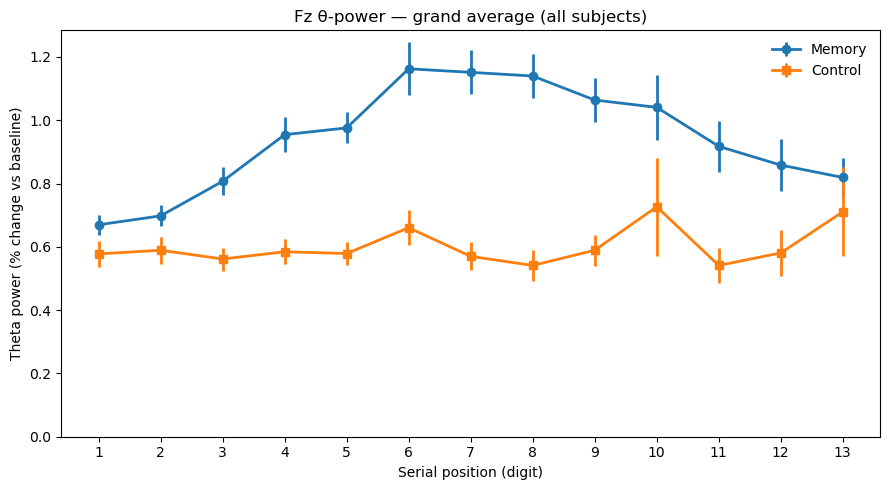


✅  Figure saved to C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2\theta_Fz_grandavg.png


In [28]:

from __future__ import annotations
import pathlib, re, sys, logging
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem

# ---------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------
OUTPUT_ROOT   = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2")
CHANNEL       = "Fz"
DIGIT_SPACING = 2.0          # seconds between digit onsets
WINDOW_LEN    = 2.0          # analyse full 2‑s presentation window
MAX_LOAD      = 13           # longest sequence length in experiment
MIN_EPOCHS    = 6            # min epochs per subject to be included

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")

# ---------------------------------------------------------------------
# 1.  Collect per‑trial Fz means by (condition, digit_pos)
# ---------------------------------------------------------------------
mem_trials  : list[np.ndarray] = []   # each → length MAX_LOAD (NaN padded)
ctrl_trials : list[np.ndarray] = []

for subj_dir in OUTPUT_ROOT.glob("sub-*/"):            # iterate subjects
    if subj_dir.name == "sub-065": 
        print("Skipping sub-65, as it is not part of the EEG dataset")
        continue
    print(f"Processing {subj_dir.name}…")
    n_epochs_subj = 0
    for cond in ("memory", "control"):
        for csv_path in subj_dir.glob(f"{cond}/*/epoch_*.csv"):
            # load CSV (skip header lines that start with '#')
            df = pd.read_csv(csv_path, comment="#")
            if CHANNEL not in df.columns:
                logging.warning("%s – missing %s column", csv_path.name, CHANNEL)
                continue

            time_s = df["time"].values
            power  = df[CHANNEL].values

            # derive load from parent folder name (05/09/13 → 5/9/13)
            load_m = int(csv_path.parent.name)
            v = np.full(MAX_LOAD, np.nan)

            for pos in range(1, load_m + 1):
                t0, t1 = (pos-1)*DIGIT_SPACING, (pos-1)*DIGIT_SPACING + WINDOW_LEN
                idx = np.flatnonzero((time_s >= t0) & (time_s < t1))
                if idx.size:
                    v[pos-1] = np.nanmean(power[idx])

            if cond == "memory":
                mem_trials.append(v)
            else:
                ctrl_trials.append(v)
            n_epochs_subj += 1

    if n_epochs_subj < MIN_EPOCHS:
        logging.info("%s – only %d epochs, excluding subject", subj_dir.name, n_epochs_subj)
        mem_trials  = mem_trials[:-n_epochs_subj]   # drop last added rows
        ctrl_trials = ctrl_trials[:-n_epochs_subj]

mem_all  = np.asarray(mem_trials,  dtype=float)
ctrl_all = np.asarray(ctrl_trials, dtype=float)

# ---------------------------------------------------------------------
# 2.  Plot
# ---------------------------------------------------------------------
X_POS = np.arange(1, MAX_LOAD+1)
plt.figure(figsize=(9,5))
plt.errorbar(X_POS, np.nanmean(mem_all,axis=0),
             yerr=sem(mem_all,axis=0,nan_policy='omit'),
             marker='o',label='Memory',linewidth=2)
plt.errorbar(X_POS, np.nanmean(ctrl_all,axis=0),
             yerr=sem(ctrl_all,axis=0,nan_policy='omit'),
             marker='s',label='Control',linewidth=2)
plt.xlabel('Serial position (digit)')
plt.ylabel('Theta power (% change vs baseline)')
plt.title('Fz θ‑power — grand average (all subjects)')
plt.xticks(X_POS)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.tight_layout()

out_fig = OUTPUT_ROOT / 'theta_Fz_grandavg.png'
plt.savefig(out_fig, dpi=300)
plt.show()

print(f"\n✅  Figure saved to {out_fig}")


Loading sub-032…
Loading sub-033…
Loading sub-034…
Loading sub-035…
Loading sub-036…
Loading sub-038…
Loading sub-039…
Loading sub-040…
Loading sub-041…
Loading sub-042…
Loading sub-043…
Loading sub-044…
Loading sub-045…
Loading sub-046…
Loading sub-047…
Loading sub-048…
Loading sub-049…
Loading sub-050…
Loading sub-051…
Loading sub-052…
Loading sub-054…
Loading sub-055…
Loading sub-056…
Loading sub-057…
Loading sub-058…
Loading sub-059…
Loading sub-060…
Loading sub-061…
Loading sub-062…
Loading sub-063…
Loading sub-064…
Loading sub-065…
Loading sub-067…
Loading sub-068…
Loading sub-069…
Loading sub-070…
Loading sub-071…
Loading sub-072…
Loading sub-073…
Loading sub-074…
Loading sub-075…
Loading sub-076…
Loading sub-077…
Loading sub-078…
Loading sub-079…
Loading sub-080…
Loading sub-081…
Loading sub-082…
Loading sub-083…
Loading sub-084…
Loading sub-085…
Loading sub-086…
Loading sub-087…
Loading sub-088…
Loading sub-089…
Loading sub-090…
Loading sub-091…
Loading sub-092…
Loading sub-09

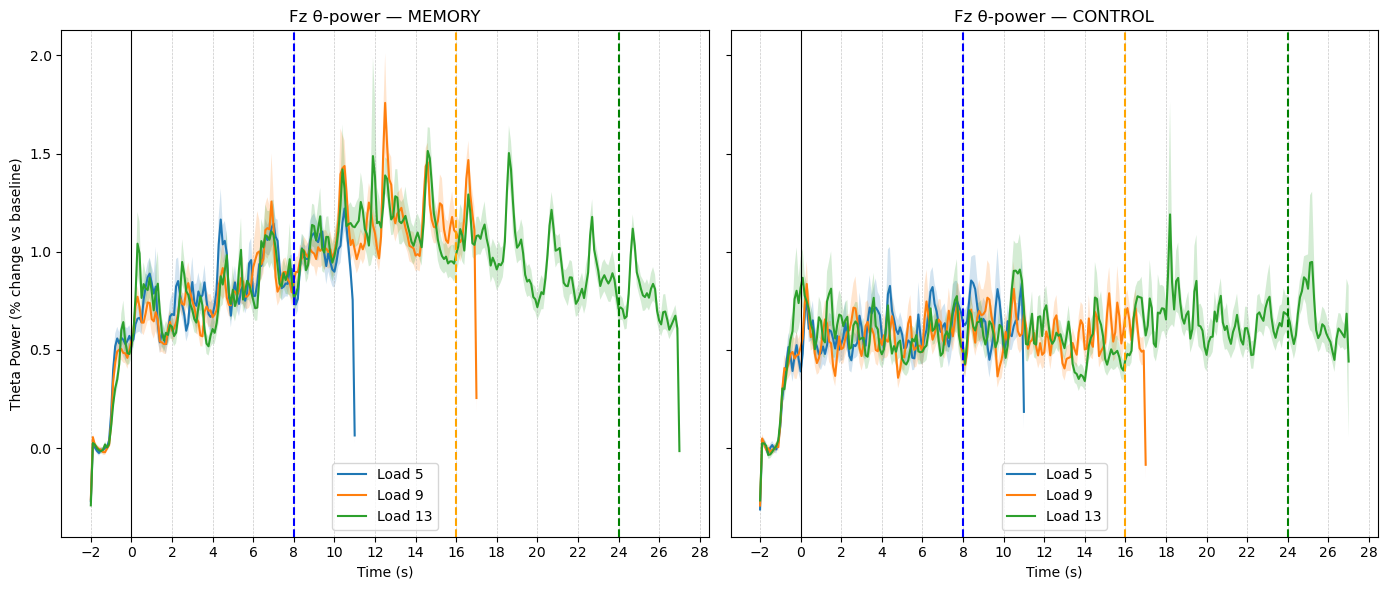

In [31]:
# -*- coding: utf-8 -*-
"""
Grand‑average θ‑power at Fz — pupil‑style figure
================================================

This script reproduces Clara‑style *dual‑panel* plots (Memory vs Control,
colour‑coded by load) but now for **theta‑band power at Fz** as extracted by
*eeg_epoch_export.py*.

Directory layout expected
-------------------------
```
<EEG_EPOCH_ROOT>/
    sub‑01/
        memory/05/epoch_0001.csv, ...
        memory/09/...
        memory/13/...
        control/05/...
        ...
```
Each CSV has the first two lines commented with ``#`` and then columns:
``time, AFz, AF3, ..., Fz, ..., Cz, ...``.

Run the script with:
```bash
python plot_theta_fz.py --root /path/to/eeg_epochs  --savefig grand_Fz.png
```
"""

from __future__ import annotations
import argparse
import pathlib
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem

# -----------------------------------------------------------------------------
#  Helpers
# -----------------------------------------------------------------------------

FZ_COL = "Fz"          # channel name exactly as in the CSV header
LOADS  = [5, 9, 13]


def load_epochs(root: pathlib.Path) -> List[pd.DataFrame]:
    """Walk the directory tree and load every epoch CSV (with metadata)."""
    all_epochs: List[pd.DataFrame] = []

    for sub_dir in sorted(root.glob("sub-*")):
        #if sub_dir.name == "sub-041": 
            #print("Skipping sub-65, as it is not part of the EEG dataset")
            #break
        print(f"Loading {sub_dir.name}…")
        for cond_dir in (sub_dir / "memory", sub_dir / "control"):
            if not cond_dir.exists():
                continue
            condition = cond_dir.name  # memory / control
            for load_dir in cond_dir.glob("*"):
                if not load_dir.is_dir():
                    continue
                try:
                    load_val = int(load_dir.name)
                except ValueError:
                    continue
                for csv_file in load_dir.glob("epoch_*.csv"):
                    df = pd.read_csv(csv_file, comment="#")
                    if FZ_COL not in df.columns:
                        raise ValueError(f"{csv_file} lacks column {FZ_COL}")
                    ep = df[["time", FZ_COL]].copy()
                    ep.rename(columns={FZ_COL: "theta"}, inplace=True)
                    ep["condition"] = condition
                    ep["load"] = load_val
                    all_epochs.append(ep)
    return all_epochs


def group_and_average(all_epochs: List[pd.DataFrame]) -> Tuple[Dict[int, Tuple[pd.Series, pd.Series]], Dict[int, Tuple[pd.Series, pd.Series]]]:
    """Return averaged_mem, averaged_ctrl as dicts keyed by load."""
    groups_mem: Dict[int, List[pd.DataFrame]] = {l: [] for l in LOADS}
    groups_ctrl: Dict[int, List[pd.DataFrame]] = {l: [] for l in LOADS}

    for ep in all_epochs:
        load_val = int(ep["load"].iloc[0])
        if ep["condition"].iloc[0] == "control":
            groups_ctrl.setdefault(load_val, []).append(ep)
        else:
            groups_mem.setdefault(load_val, []).append(ep)

    def compute_avg(groups: Dict[int, List[pd.DataFrame]]):
        averaged: Dict[int, Tuple[pd.Series, pd.Series]] = {}
        for load, trials in groups.items():
            if len(trials) == 0:
                continue
            # Align by trimming to the shortest trial length
            min_len = min(len(t) for t in trials)
            trimmed = [t.iloc[:min_len]["theta"].reset_index(drop=True) for t in trials]
            concat_df = pd.concat(trimmed, axis=1)
            mean_ts = concat_df.mean(axis=1)
            sem_ts  = concat_df.apply(sem, axis=1, nan_policy="omit")
            # time vector from first trial (all same after trimming)
            time_idx = trials[0].iloc[:min_len]["time"].values
            mean_ts.index = time_idx
            sem_ts.index  = time_idx
            averaged[load] = (mean_ts, sem_ts)
        return averaged

    return compute_avg(groups_mem), compute_avg(groups_ctrl)


def plot_averages(averaged_mem, averaged_ctrl, savefig: pathlib.Path | None = None):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # MEMORY
    for load in sorted(averaged_mem.keys()):
        mean_ts, sem_ts = averaged_mem[load]
        axs[0].plot(mean_ts.index, mean_ts, label=f"Load {load}")
        axs[0].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Theta Power (% change vs baseline)")
    axs[0].set_title("Fz θ‑power — MEMORY")
    axs[0].axvline(0,  color="k", linewidth=0.8)
    axs[0].axvline(8,  color="b", linestyle="--")
    axs[0].axvline(16, color="orange", linestyle="--")
    axs[0].axvline(24, color="g", linestyle="--")
    axs[0].legend()
    axs[0].set_xticks(np.arange(-2, 29, 2))
    axs[0].grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    # CONTROL
    for load in sorted(averaged_ctrl.keys()):
        mean_ts, sem_ts = averaged_ctrl[load]
        axs[1].plot(mean_ts.index, mean_ts, label=f"Load {load}")
        axs[1].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2)
    axs[1].set_xlabel("Time (s)")
    axs[1].set_title("Fz θ‑power — CONTROL")
    axs[1].axvline(0,  color="k", linewidth=0.8)
    axs[1].axvline(8,  color="b", linestyle="--")
    axs[1].axvline(16, color="orange", linestyle="--")
    axs[1].axvline(24, color="g", linestyle="--")
    axs[1].legend()
    axs[1].set_xticks(np.arange(-2, 29, 2))
    axs[1].grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    if savefig:
        savefig.parent.mkdir(exist_ok=True, parents=True)
        fig.savefig(savefig, dpi=300)
        print("Saved figure to", savefig)
    else:
        plt.show()


# -----------------------------------------------------------------------------
#  CLI / direct run
# -----------------------------------------------------------------------------

def main():

    all_epochs = load_epochs(pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2"))
    avg_mem, avg_ctrl = group_and_average(all_epochs)
    plot_averages(avg_mem, avg_ctrl, savefig=False)


if __name__ == "__main__":
    main()

In [16]:
csv = pathlib.Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed\sub-048\memory\13\epoch_005.csv")
df  = pd.read_csv(csv, comment="#")

print(df.head(50)[["time", "Fz"]])

    time      Fz
0   -2.0  0.1466
1   -1.9 -0.1935
2   -1.8  0.3768
3   -1.7  0.7311
4   -1.6  0.6724
5   -1.5  0.0719
6   -1.4 -0.5919
7   -1.3 -0.6443
8   -1.2 -0.1725
9   -1.1 -0.6878
10  -1.0 -0.2226
11  -0.9 -0.3227
12  -0.8  0.0919
13  -0.7 -0.2762
14  -0.6 -0.5317
15  -0.5 -0.1505
16  -0.4  0.8358
17  -0.3  1.1594
18  -0.2 -0.1702
19  -0.1 -0.2611
20   0.0 -0.6817
21   0.1 -0.8696
22   0.2 -0.3478
23   0.3  0.9316
24   0.4  3.4223
25   0.5  2.2655
26   0.6  0.1296
27   0.7 -0.1923
28   0.8 -0.4674
29   0.9 -0.4657
30   1.0 -0.6427
31   1.1 -0.4105
32   1.2  0.8854
33   1.3  1.5312
34   1.4 -0.2206
35   1.5  0.9690
36   1.6  0.7461
37   1.7 -0.0211
38   1.8 -0.1778
39   1.9  0.1108
40   2.0  0.2860
41   2.1 -0.1030
42   2.2 -0.5645
43   2.3 -0.5680
44   2.4 -0.7265
45   2.5 -0.6464
46   2.6  0.3603
47   2.7  0.7697
48   2.8  0.8013
49   2.9  0.0313
